### Prepare Dataset

In [ ]:
import pandas as pd
import numpy as np

# Load your time-series data
df = pd.read_csv("../Data/time_series_data.csv")

# Select features
data = df[["tds", "ntu", "temp"]].values

### Normalize Data

In [7]:
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

joblib.dump(scaler, "lstm_scaler.pkl")

['lstm_scaler.pkl']

### Create Sequences

In [8]:
def create_sequences(data, seq_length=10):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])  # predict TDS

    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, seq_length=10)

### Train LSTM Model

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(10, 3)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.fit(X, y, epochs=20, batch_size=16)

model.save("lstm_model.keras")

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0383
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0157
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0139
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0120
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0104
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0091
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0076
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0075
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0066
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0062
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0053
Epoch 12/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0058
Epoch 13/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0055
Epoch 14/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0053
Epoch 15/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0048
Epoch 16/20
62/62 ━

### Real-Time Prediction

In [16]:
from tensorflow.keras.models import load_model
import numpy as np
import joblib

model = load_model("lstm_model.keras")
scaler = joblib.load("lstm_scaler.pkl")

buffer = []

def predict_filter_status(tds, ntu, temp):

    global buffer

    buffer.append([tds, ntu, temp])

    # Wait until enough data
    if len(buffer) < 10:
        return "COLLECTING"

    if len(buffer) > 10:
        buffer.pop(0)

    # Normalize
    input_scaled = scaler.transform(buffer)

    input_seq = np.array(input_scaled).reshape(1, 10, 3)

    predicted_scaled = model.predict(input_seq)[0][0]

    # Convert back to real value
    dummy = [[predicted_scaled, 0, 0]]
    predicted_tds = scaler.inverse_transform(dummy)[0][0]

    # Decision
    if predicted_tds > 100:
        return "REPLACE_NOW"
    elif predicted_tds > 70:
        return "REPLACE_SOON"
    else:
        return "HEALTHY"

### Example 1

In [28]:
import numpy as np
import joblib
from tensorflow.keras.models import load_model

# LOAD MODEL + SCALER
model = load_model("lstm_model.keras")
scaler = joblib.load("lstm_scaler.pkl")

# CONFIG
SEQ_LEN = 10
buffer = []

# PREDICTION FUNCTION
def predict_filter_status(tds, ntu, temp):
    global buffer

    # Add new data
    buffer.append([tds, ntu, temp])

    # Wait until buffer full
    if len(buffer) < SEQ_LEN:
        return "COLLECTING"

    # Keep fixed size
    if len(buffer) > SEQ_LEN:
        buffer.pop(0)

    # Normalize input
    input_scaled = scaler.transform(buffer)

    # Reshape for LSTM
    input_seq = np.array(input_scaled).reshape(1, SEQ_LEN, 3)

    # Predict next TDS (scaled)
    pred_scaled = model.predict(input_seq, verbose=0)[0][0]

    # Convert back to real TDS
    dummy = np.array([[pred_scaled, 0, 0]])
    predicted_tds = scaler.inverse_transform(dummy)[0][0]


    # DECISION LOGIC

    if predicted_tds > 1000:
        status = "REPLACE_NOW"
    elif predicted_tds > 700:
        status = "REPLACE_SOON"
    else:
        status = "HEALTHY"

    return status, round(predicted_tds, 2)


# TEST INPUT SEQUENCE
if __name__ == "__main__":

    # Simulated real-time data (increasing trend)
    test_stream = [
        (200, 5, 25),
        (220, 6, 25),
        (240, 7, 26),
        (260, 8, 26),
        (300, 10, 27),
        (350, 12, 28),
        (420, 15, 29),
        (500, 18, 30),
        (600, 20, 31),
        (700, 25, 32),
        (800, 30, 33),
        (900, 35, 34),
    ]

    print("\n--- LSTM FILTER LIFE TEST ---\n")

    for tds, ntu, temp in test_stream:

        result = predict_filter_status(tds, ntu, temp)

        print(f"Input → TDS:{tds}, NTU:{ntu}, TEMP:{temp}")

        if result == "COLLECTING":
            print("Status → COLLECTING DATA...\n")
        else:
            status, pred_tds = result
            print(f"Predicted Next TDS → {pred_tds}")
            print(f"Filter Status → {status}\n")


--- LSTM FILTER LIFE TEST ---

Input → TDS:200, NTU:5, TEMP:25
Status → COLLECTING DATA...

Input → TDS:220, NTU:6, TEMP:25
Status → COLLECTING DATA...

Input → TDS:240, NTU:7, TEMP:26
Status → COLLECTING DATA...

Input → TDS:260, NTU:8, TEMP:26
Status → COLLECTING DATA...

Input → TDS:300, NTU:10, TEMP:27
Status → COLLECTING DATA...

Input → TDS:350, NTU:12, TEMP:28
Status → COLLECTING DATA...

Input → TDS:420, NTU:15, TEMP:29
Status → COLLECTING DATA...

Input → TDS:500, NTU:18, TEMP:30
Status → COLLECTING DATA...

Input → TDS:600, NTU:20, TEMP:31
Status → COLLECTING DATA...

Input → TDS:700, NTU:25, TEMP:32
Predicted Next TDS → 776.84
Filter Status → REPLACE_SOON

Input → TDS:800, NTU:30, TEMP:33
Predicted Next TDS → 977.12
Filter Status → REPLACE_SOON

Input → TDS:900, NTU:35, TEMP:34
Predicted Next TDS → 1209.2
Filter Status → REPLACE_NOW



### FULL DATA PREPARATION CODE

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import joblib

# LOAD DATA
df = pd.read_csv("../Data/time_series_data.csv")

# SELECT FEATURES
data = df[["tds", "ntu", "temp"]].values

# NORMALIZE DATA
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Save scaler
joblib.dump(scaler, "lstm_scaler.pkl")

# CREATE SEQUENCES
def create_sequences(data, seq_length=10):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])  # predict TDS

    return np.array(X), np.array(y)

SEQ_LEN = 10
X, y = create_sequences(data_scaled, SEQ_LEN)

print("Total sequences:", len(X))

# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# SAVE FILES
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

print("Data saved successfully!")

Total sequences: 990
✅ Data saved successfully!


### Checking the Model Prediction

In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import load_model
import joblib

# Load model + scaler
model = load_model("lstm_model.keras")
scaler = joblib.load("lstm_scaler.pkl")

# Load test data (scaled sequences)
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

# Predict
y_pred = model.predict(X_test)

# Convert back to real values
y_test_real = scaler.inverse_transform(
    np.hstack([y_test.reshape(-1,1), np.zeros((len(y_test),2))])
)[:,0]

y_pred_real = scaler.inverse_transform(
    np.hstack([y_pred, np.zeros((len(y_pred),2))])
)[:,0]

# Metrics
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
MAE: 21.30017344861735
RMSE: 26.800051074553004
R2 Score: 0.986207329508611


### Plot Training Dataset

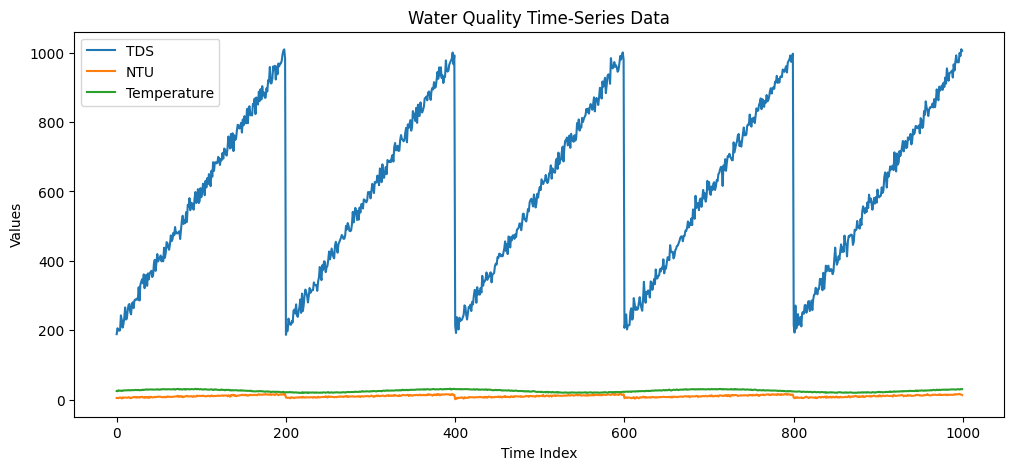

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../Data/time_series_data.csv")

plt.figure(figsize=(12,5))

plt.plot(df["tds"], label="TDS")
plt.plot(df["ntu"], label="NTU")
plt.plot(df["temp"], label="Temperature")

plt.title("Water Quality Time-Series Data")
plt.xlabel("Time Index")
plt.ylabel("Values")
plt.legend()
plt.show()

### LSTM Prediction vs Actual

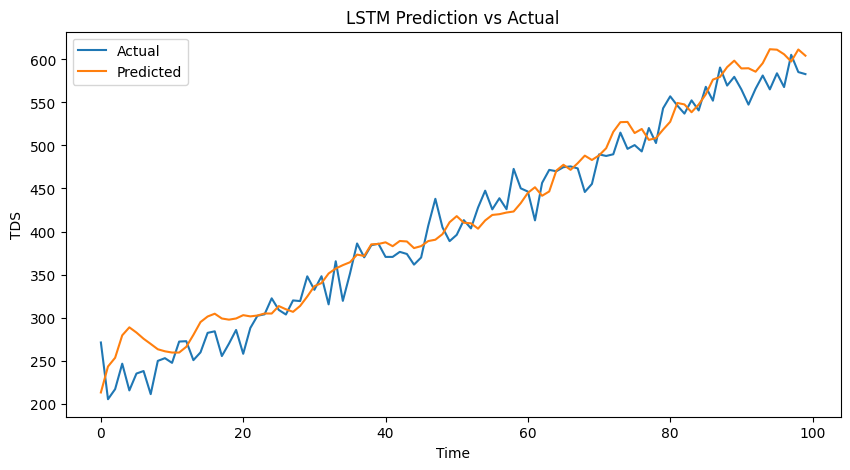

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_real[:100], label="Actual")
plt.plot(y_pred_real[:100], label="Predicted")

plt.xlabel("Time")
plt.ylabel("TDS")
plt.title("LSTM Prediction vs Actual")
plt.legend()
plt.show()

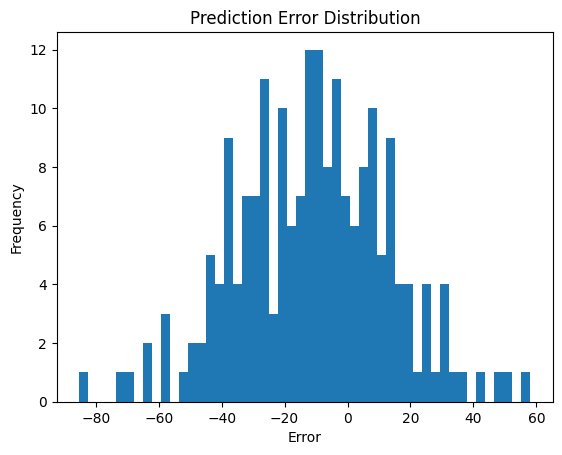

In [24]:
errors = y_test_real - y_pred_real

plt.hist(errors, bins=50)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()